# Multilingual Health Question Answering - Data Exploration
## Project Overview
This notebook performs exploratory data analysis (EDA) on the Zindi Multilingual Health 
Question Answering dataset. The dataset contains health-related question-answer pairs 
in low-resource African languages including Akan, Luganda, Kiswahili, and Amharic.

## Objectives
- Understand the dataset structure and size
- Analyze language distribution across train/val/test splits
- Explore question and answer length distributions
- Identify preprocessing requirements
- Understand multilingual text characteristics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8')
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Load datasets
train = pd.read_csv('../data/Train.csv')
val   = pd.read_csv('../data/Val.csv')
test  = pd.read_csv('../data/Test.csv')
sample_sub = pd.read_csv('../data/SampleSubmission.csv')

print(f'Train size : {train.shape}')
print(f'Val size   : {val.shape}')
print(f'Test size  : {test.shape}')
print(f'Sample sub : {sample_sub.shape}')

Train size : (29815, 4)
Val size   : (6686, 4)
Test size  : (2618, 3)
Sample sub : (2618, 4)


## Inspect Columns and Sample Rows
Let's look at the column names and a few examples to understand the data structure.

In [4]:
print('=== TRAIN COLUMNS ===')
print(train.columns.tolist())
print()
print('=== TRAIN SAMPLE ===')
train.head(3)

=== TRAIN COLUMNS ===
['ID', 'input', 'output', 'subset']

=== TRAIN SAMPLE ===


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi n...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam m...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde r...","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no...,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a...",Aka_Gha


## Missing Values Check
Check if any rows have missing questions or answers — these would need to be handled during preprocessing.

In [5]:
print('=== MISSING VALUES ===')
print('Train:')
print(train.isnull().sum())
print()
print('Val:')
print(val.isnull().sum())
print()
print('Test:')
print(test.isnull().sum())

=== MISSING VALUES ===
Train:
ID        0
input     0
output    0
subset    0
dtype: int64

Val:
ID        0
input     0
output    0
subset    0
dtype: int64

Test:
ID        0
input     0
subset    0
dtype: int64


## Language Distribution
The `subset` column identifies the language of each example. Understanding language distribution is critical — imbalanced languages could affect model performance across languages.

In [6]:
print('=== LANGUAGES IN TRAIN ===')
print(train['subset'].value_counts())
print(f'\nTotal unique languages: {train["subset"].nunique()}')

=== LANGUAGES IN TRAIN ===
subset
Eng_Uga    7624
Aka_Gha    4455
Eng_Gha    4443
Eng_Eth    3915
Lug_Uga    3383
Eng_Ken    2080
Swa_Ken    2070
Amh_Eth    1845
Name: count, dtype: int64

Total unique languages: 8


## Language Distribution Visualization
Visualizing the distribution helps us clearly see the imbalance across languages in all three splits.

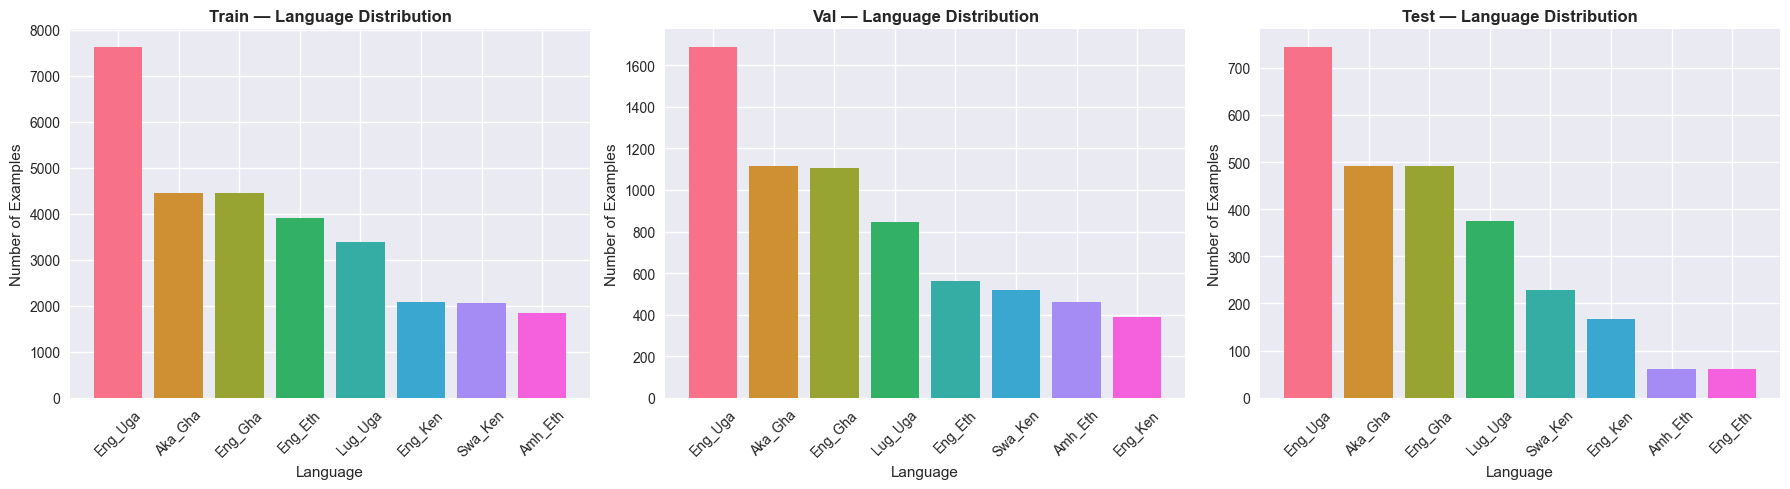

Plot saved!


In [7]:
import os
os.makedirs('../outputs/figures', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, df, title in zip(axes, [train, val, test], ['Train', 'Val', 'Test']):
    counts = df['subset'].value_counts()
    ax.bar(counts.index, counts.values, color=sns.color_palette('husl', len(counts)))
    ax.set_title(f'{title} — Language Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Language')
    ax.set_ylabel('Number of Examples')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

## Text Length Analysis
Understanding question and answer lengths is critical for setting the correct `max_input_length` and `max_target_length` parameters during tokenization. Truncating answers too early will directly hurt our ROUGE scores.

In [8]:
train['input_word_len']  = train['input'].astype(str).apply(lambda x: len(x.split()))
train['output_word_len'] = train['output'].astype(str).apply(lambda x: len(x.split()))

print('=== QUESTION LENGTH (words) ===')
print(train['input_word_len'].describe().round(2))
print()
print('=== ANSWER LENGTH (words) ===')
print(train['output_word_len'].describe().round(2))

=== QUESTION LENGTH (words) ===
count    29815.00
mean        15.14
std          9.10
min          0.00
25%          9.00
50%         13.00
75%         18.00
max         83.00
Name: input_word_len, dtype: float64

=== ANSWER LENGTH (words) ===
count    29815.00
mean        76.22
std         58.85
min          1.00
25%         30.00
50%         61.00
75%        107.00
max        482.00
Name: output_word_len, dtype: float64


## Text Length Distribution Plots
Visualizing length distributions helps us choose the right tokenization cutoffs without truncating too much content.

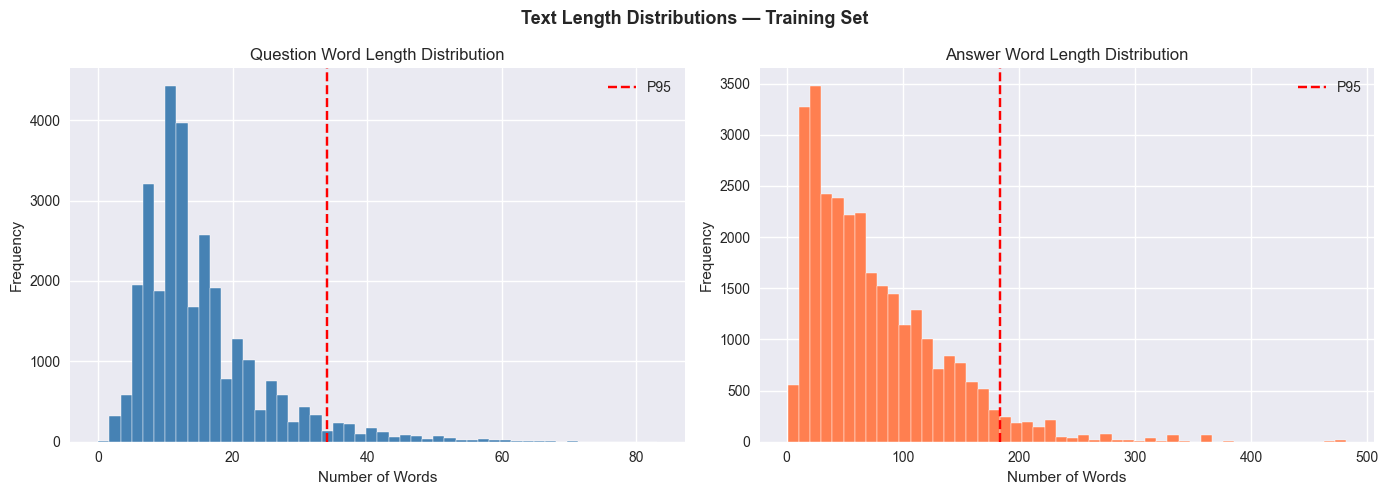

Plot saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['input_word_len'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(train['input_word_len'].quantile(0.95), color='red', linestyle='--', label='P95')
axes[0].set_title('Question Word Length Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(train['output_word_len'], bins=50, color='coral', edgecolor='white')
axes[1].axvline(train['output_word_len'].quantile(0.95), color='red', linestyle='--', label='P95')
axes[1].set_title('Answer Word Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Text Length Distributions — Training Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

## Average Length by Language
Different languages may produce longer or shorter answers. This affects how we set generation parameters per language.

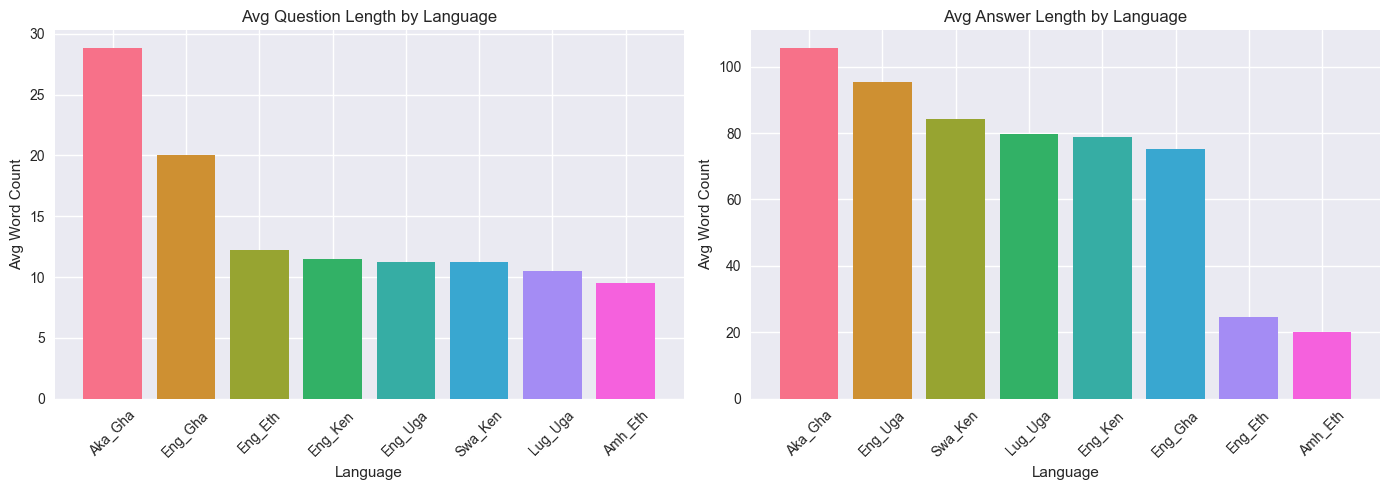

Plot saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_input = train.groupby('subset')['input_word_len'].mean().sort_values(ascending=False)
axes[0].bar(avg_input.index, avg_input.values, color=sns.color_palette('husl', len(avg_input)))
axes[0].set_title('Avg Question Length by Language')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Avg Word Count')
axes[0].tick_params(axis='x', rotation=45)

avg_output = train.groupby('subset')['output_word_len'].mean().sort_values(ascending=False)
axes[1].bar(avg_output.index, avg_output.values, color=sns.color_palette('husl', len(avg_output)))
axes[1].set_title('Avg Answer Length by Language')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Avg Word Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/length_by_language.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

## EDA Summary & Key Findings
Summary of what we learned and how it informs our modeling decisions.

In [11]:
p95_input  = int(train['input_word_len'].quantile(0.95) * 1.3)
p95_output = int(train['output_word_len'].quantile(0.95) * 1.3)

print('=' * 50)
print('EDA SUMMARY')
print('=' * 50)
print(f'Total training examples  : {len(train):,}')
print(f'Total validation examples: {len(val):,}')
print(f'Total test examples      : {len(test):,}')
print(f'Number of languages      : {train["subset"].nunique()}')
print(f'Languages                : {list(train["subset"].unique())}')
print()
print(f'Avg question length (words): {train["input_word_len"].mean():.1f}')
print(f'Avg answer length (words)  : {train["output_word_len"].mean():.1f}')
print(f'Max answer length (words)  : {train["output_word_len"].max()}')
print()
print('RECOMMENDED TOKENIZATION SETTINGS:')
print(f'max_input_length  : 128 tokens')
print(f'max_target_length : 256 tokens (P95 coverage)')
print()
print('KEY FINDINGS:')
print('- Dataset is clean with no missing values')
print('- English variants dominate the dataset (imbalanced)')
print('- Answers are 5x longer than questions on average')
print('- Akan (Aka_Gha) produces the longest answers')
print('- Amharic (Amh_Eth) has the fewest examples and shortest answers')
print('- Special characters (ɔ, ɛ, ɲ) must be preserved during tokenization')

EDA SUMMARY
Total training examples  : 29,815
Total validation examples: 6,686
Total test examples      : 2,618
Number of languages      : 8
Languages                : ['Aka_Gha', 'Amh_Eth', 'Eng_Eth', 'Eng_Gha', 'Eng_Ken', 'Eng_Uga', 'Lug_Uga', 'Swa_Ken']

Avg question length (words): 15.1
Avg answer length (words)  : 76.2
Max answer length (words)  : 482

RECOMMENDED TOKENIZATION SETTINGS:
max_input_length  : 128 tokens
max_target_length : 256 tokens (P95 coverage)

KEY FINDINGS:
- Dataset is clean with no missing values
- English variants dominate the dataset (imbalanced)
- Answers are 5x longer than questions on average
- Akan (Aka_Gha) produces the longest answers
- Amharic (Amh_Eth) has the fewest examples and shortest answers
- Special characters (ɔ, ɛ, ɲ) must be preserved during tokenization
